# Homework 7: State Radio Analysis
## CSC 2053 - Platform Based Computing - Mr. Nick Langan

**Name:** Kyle Junker  
**State Chosen:** NY
---

## Introduction

In this assignment, you'll analyze FM radio station data from a U.S. state of your choice. You'll perform data cleaning, exploratory analysis, geographic calculations, and create visualizations to understand the radio landscape in your state.

### Dataset Information
The data comes from the RadioLand database and includes information about FM radio stations including their location, broadcast power, programming format, ownership, and affiliations.

**Important Note**: The longitude values in the dataset are stored as POSITIVE numbers. For the Western Hemisphere (United States), these should be NEGATIVE. You'll fix this in Question 2!

## Setup: Import Required Libraries

Run this cell first to import all necessary Python libraries.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import radians, cos, sin, asin, sqrt

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


---

## Question 1: Load and Inspect the Data (10 points)

**Task**:
1. Set the `STATE` variable to your chosen state's two-letter abbreviation (e.g., 'FL', 'NY', 'CA')
2. Load the CSV file into a Pandas DataFrame
3. Display the first 10 rows
4. Print the shape (number of rows and columns)
5. Display the column names and data types

**Starter Code Provided Below:**

In [2]:
# Step 1: Set your state abbreviation (CHANGE THIS!)
STATE = 'NY'  # <<< CHANGE THIS to your chosen state (e.g., 'NY', 'CA', 'TX')

# Step 2: Construct the URL to the CSV file
url = f'https://raw.githubusercontent.com/CSC-2053-100-Fall25/homework-7-state-radio-analysis/main/radioland_states/fm_{STATE}.csv'

# Step 3: Load the data into a DataFrame
df = pd.read_csv(url)

print(f"Data loaded successfully for {STATE}!")
print(f"\nDataset contains {len(df)} FM radio stations\n")

# Step 4: Display first 10 rows
print("First 10 stations:")
display(df.head(10))

Data loaded successfully for NY!

Dataset contains 828 FM radio stations

First 10 stations:


,frequency,callsign,city,state,power,lat,lon,height,slogan,owner,format,mlb,nfl,nba,nhl,market,rank,npr
0,90.5,W213CH,PLATTSBURGH,NY,0.010,44.770278,73.612778,28.0,AIR1,EDUCATIONAL MEDIA FOUNDATION,Christian Contemporary,NaN,NaN,NaN,NaN,NaN,NaN,False
1,91.5,W218DB,ROME,NY,0.250,43.219889,75.426833,17.0,24 HOUR SOURCE FOR NPR NEWS,STATE UNIVERSITY OF NEW YORK,News,NaN,NaN,NaN,NaN,NaN,NaN,True
2,92.3,W222DA,UTICA,NY,0.250,43.144167,75.178889,45.0,NEWSRADIO 950,"TOWNSQUARE MEDIA LICENSEE OF UTICA/ROME, INC.",News,NaN,NaN,NaN,NaN,NaN,NaN,False
3,93.3,W227EF,PORT JERVIS,NY,0.250,41.363694,74.677639,45.0,WALL RADIO,NaN,Classic Hits,NaN,NaN,NaN,NaN,NaN,NaN,False
4,94.1,W231EH,BLUFF POINT,NY,0.250,42.614722,77.128056,50.0,WYLF 850 AM AND 93.9 FM,"WYLF Radio, LLC",Classic Hits,NaN,NaN,NaN,NaN,NaN,NaN,False
5,94.5,W233DD,MIDDLETOWN,NY,0.099,41.454528,74.417917,15.0,101.5 WPDH - THE HOME OF ROCK & ROLL,"Digital Radio Broadcasting, Inc.",Rock,NaN,NaN,NaN,NaN,NaN,NaN,False
6,95.9,W240EM,CANANDAIGUA,NY,0.250,42.746444,77.426083,32.0,CLASSIC COUNTRY WOKR 1310 AM/95.5 FM,"1310 FLX RADIO, INC.",Country,NaN,NaN,NaN,NaN,NaN,NaN,False
7,95.9,W240EO,BRENTWOOD,NY,0.250,40.807222,73.179444,80.0,RADIO CANTICO NUEVO,"CANTICO NUEVO MINISTRY, INC.",Contemporary Christian,NaN,NaN,NaN,NaN,NaN,NaN,False
8,96.1,W241DM,SARATOGA SPRINGS,NY,0.075,43.020056,73.524000,20.0,STAR RADIO,LOUD MEDIA LLC,Classic Hits,NaN,NaN,NaN,NaN,NaN,NaN,False
9,97.1,W246EA,ROCHESTER,NY,0.250,43.154722,77.604167,135.0,NaN,"Ibero American Action League, Inc.",Tropical,NaN,NaN,NaN,NaN,NaN,NaN,False


In [3]:
# Step 5: Display shape and data types
# YOUR CODE HERE
print("\nDataFrame Shape (rows, columns):")
print(df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
# Hint: Use df.shape, df.columns, and df.dtypes



DataFrame Shape (rows, columns):
(828, 18)

Column Names:
['frequency', 'callsign', 'city', 'state', 'power', 'lat', 'lon', 'height', 'slogan', 'owner', 'format', 'mlb', 'nfl', 'nba', 'nhl', 'market', 'rank', 'npr']

Data Types:
frequency    float64
callsign      object
city          object
state         object
power        float64
lat          float64
lon          float64
height       float64
slogan        object
owner         object
format        object
mlb           object
nfl           object
nba           object
nhl           object
market        object
rank         float64
npr             bool
dtype: object


**Written Response**: In 1-2 sentences, describe the size of the dataset and what types of information are included.

We have 828 radio stations, whith information about their city, frequency, owners etc.

---

## Question 2: Fix Longitude Values (10 points)

**Task**:
The longitude values are currently POSITIVE, but for locations in the Western Hemisphere (United States), they should be NEGATIVE.

1. Convert all longitude values from positive to negative by multiplying by -1
2. Verify the change by displaying the min and max longitude values before and after

**Expected Result**: Longitude values should range from approximately -65 to -125 degrees (depending on your state)

In [ ]:
# Display longitude statistics BEFORE correction
print("BEFORE correction:")
print(f"Longitude range: {df['lon'].min():.2f} to {df['lon'].max():.2f}")

# YOUR CODE HERE: Convert longitude to negative
# Hint: df['lon'] = df['lon'] * ?

# Display longitude statistics AFTER correction
print("\nAFTER correction:")
print(f"Longitude range: {df['lon'].min():.2f} to {df['lon'].max():.2f}")
print("\n✓ Longitude values corrected!")

---

## Question 3: NPR and Sports Affiliations (10 points)

**Task**:
1. Count how many NPR-affiliated stations are in your state (where `npr == True`)
2. Count how many stations have MLB affiliations (where `mlb` is not empty)
3. Count how many stations have NFL affiliations (where `nfl` is not empty)
4. Count how many stations have NBA affiliations (where `nba` is not empty)
5. Count how many stations have NHL affiliations (where `nhl` is not empty)
6. Calculate the total number of sports-affiliated stations (any of the above)

**Note**: Empty values in the sports columns are represented as empty strings ('')

In [ ]:
# Count NPR stations
# YOUR CODE HERE
# Hint: Use df[df['npr'] == True] or df['npr'].sum()

npr_count = # YOUR CODE

# Count sports affiliations
# YOUR CODE HERE
# Hint: Use df['mlb'] != '' to find non-empty values

mlb_count = # YOUR CODE
nfl_count = # YOUR CODE
nba_count = # YOUR CODE
nhl_count = # YOUR CODE

# Calculate total sports-affiliated stations
# Hint: A station might have multiple affiliations, so you need to count unique stations
sports_affiliated = # YOUR CODE

# Display results
print("Station Affiliations Summary")
print("=" * 40)
print(f"NPR Stations: {npr_count}")
print(f"\nSports Affiliations:")
print(f"  MLB: {mlb_count}")
print(f"  NFL: {nfl_count}")
print(f"  NBA: {nba_count}")
print(f"  NHL: {nhl_count}")
print(f"\nTotal stations with sports affiliations: {sports_affiliated}")

**Written Response**: Which sport has the most radio affiliations in your state? Why do you think that might be?

*[Your answer here]*

---

## Question 4: Top Programming Formats and Owners (15 points)

**Task**:
1. Find the top 10 most common programming formats
2. Find the top 10 station owners by number of stations
3. Create a bar chart showing the top 10 formats
4. Create a bar chart showing the top 10 owners

**Note**: Some stations may have empty format or owner fields - you should exclude these from your analysis.

In [15]:
# Filter out empty formats and get top 10
# YOUR CODE HERE
# Hint: df[df['format'] != '']['format'].value_counts().head(10)

top_formats = df[df['format'] != '']['format'].value_counts().head(10)

print("Top 10 Programming Formats:")
print(top_formats)

Top 10 Programming Formats:
format
News                      111
Religious Teaching         99
Contemporary Christian     83
Country                    79
Variety                    60
Classic Hits               54
Classic Rock               39
Adult Contemporary         35
Rock                       32
Adult Alternative          30
Name: count, dtype: int64


In [12]:
# Filter out empty owners and get top 10
# YOUR CODE HERE

top_owners = top_owners = df[df['owner'] != '']['owner'].value_counts().head(10)


print("Top 10 Station Owners:")
print(top_owners)

Top 10 Station Owners:
owner
iHeartMedia                      37
THE ST. LAWRENCE UNIVERSITY      31
WAMC                             25
FAMILY LIFE MINISTRIES, INC.     24
EDUCATIONAL MEDIA FOUNDATION     22
Townsquare License, LLC          20
Southern Belle, LLC              20
STATE UNIVERSITY OF NEW YORK     19
6 JOHNSON ROAD LICENSES, INC.    17
SOUTHERN BELLE, LLC              14
Name: count, dtype: int64


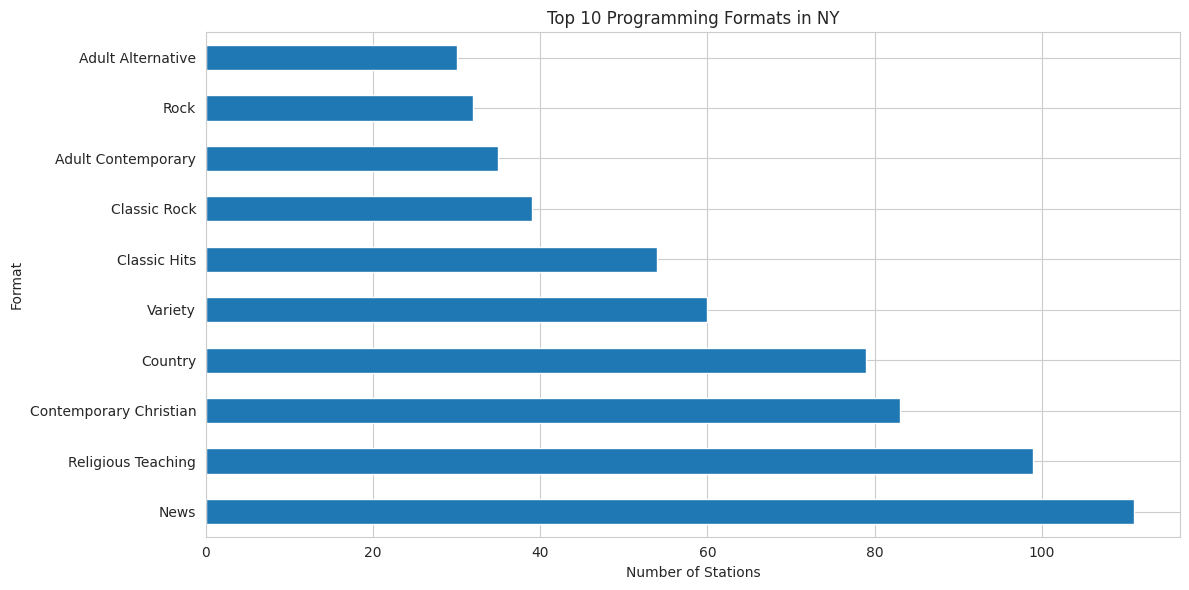

In [16]:
# Create bar chart for top formats
# YOUR CODE HERE
# Hint: Use plt.figure(), plt.bar() or top_formats.plot(kind='barh')

plt.figure(figsize=(12, 6))
top_formats.plot(kind='barh')
plt.title(f'Top 10 Programming Formats in {STATE}')
plt.xlabel('Number of Stations')
plt.ylabel('Format')
plt.tight_layout()
plt.show()

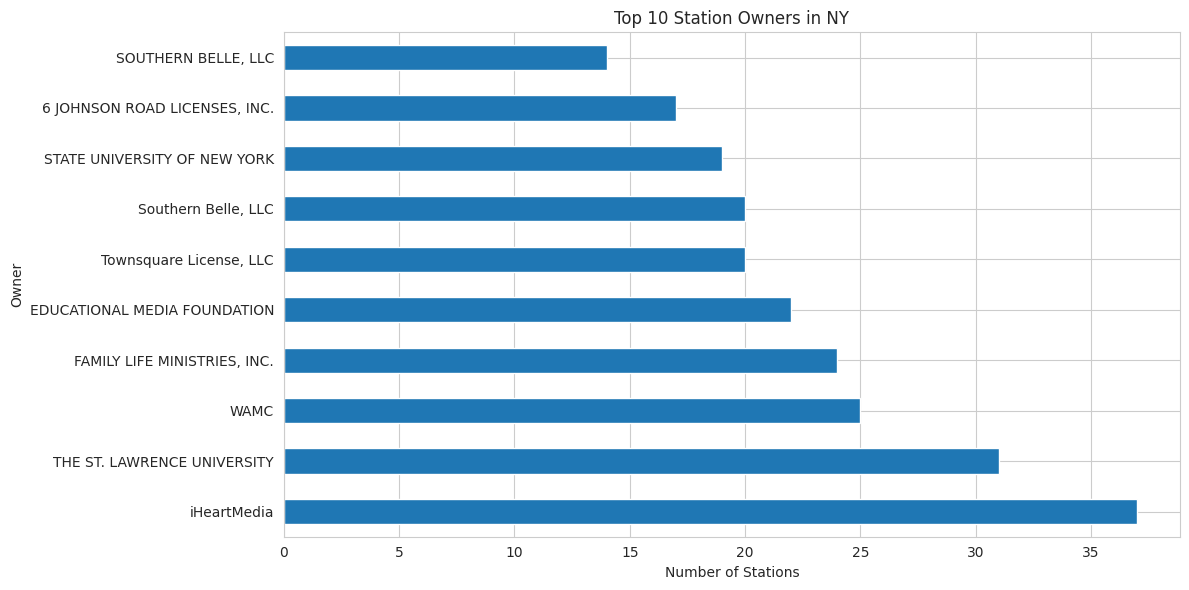

In [14]:
# Create bar chart for top owners
# YOUR CODE HERE

plt.figure(figsize=(12, 6))
top_owners.plot(kind='barh')
plt.title(f'Top 10 Station Owners in {STATE}')
plt.xlabel('Number of Stations')
plt.ylabel('Owner')
plt.tight_layout()
plt.show()

THe most popular format is news and the most popular owner is iHeartMedia.

---

## Question 5: Distance to State Capital (15 points)

**Task**:
1. Look up your state capital's coordinates (latitude, longitude)
2. Use the Haversine formula (provided below) to calculate the distance from each station to your state capital
3. Add this as a new column called `distance_to_capital_miles`
4. Display the 10 closest stations to the capital
5. Display the 10 farthest stations from the capital

**Haversine Formula** (measures distance between two points on Earth):

In [4]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate the great circle distance between two points
    on the earth (specified in decimal degrees)
    Returns distance in miles
    """
    # Convert decimal degrees to radians
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])

    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))

    # Radius of earth in miles
    miles = 3956 * c
    return miles

In [5]:
# Set your state capital coordinates
# Example for Florida (Tallahassee): capital_lat = 30.4383, capital_lon = -84.2807
# Look up your state capital's coordinates and enter them here:

capital_lat = 42.6526
capital_lon = -73.7562

print(f"State Capital coordinates: ({capital_lat}, {capital_lon})")

State Capital coordinates: (42.6526, -73.7562)


In [8]:
# Calculate distance for each station using the haversine function
# YOUR CODE HERE
# Hint: Use df.apply() with a lambda function
# Example: df['distance_to_capital_miles'] = df.apply(lambda row: haversine_distance(...), axis=1)

df['distance_to_capital_miles'] = df.apply(
    lambda row: haversine_distance(
        capital_lat,
        capital_lon,
        row['lat'],
        row['lon']
    ),
    axis=1
)
print("✓ Distance calculations complete!")
print(f"\nDistance statistics:")
print(f"  Minimum: {df['distance_to_capital_miles'].min():.2f} miles")
print(f"  Maximum: {df['distance_to_capital_miles'].max():.2f} miles")
print(f"  Average: {df['distance_to_capital_miles'].mean():.2f} miles")

✓ Distance calculations complete!

Distance statistics:
  Minimum: 6065.64 miles
  Maximum: 6350.24 miles
  Average: 6245.29 miles


In [9]:
# Display 10 closest stations

print("\n10 Closest Stations to State Capital:")
display(df.nsmallest(10, 'distance_to_capital_miles')
          [['callsign', 'city', 'distance_to_capital_miles']])

# Hint: Use df.nsmallest(10, 'distance_to_capital_miles')[['callsign', 'city', 'distance_to_capital_miles']]



10 Closest Stations to State Capital:


,callsign,city,distance_to_capital_miles
434,WCEL,PLATTSBURGH,6065.636824
420,WBTZ,PLATTSBURGH,6065.870141
0,W213CH,PLATTSBURGH,6065.882341
322,W290AT,PLATTSBURGH,6066.887118
26,WELN,ELLENBURG,6067.622009
687,WQLR,CHATEAUGAY,6067.622009
785,WWFK,PLATTSBURGH WEST,6071.392366
277,W278CS,AKWESASNE,6072.929586
282,W279DE,PLATTSBURGH,6075.386966
635,WNBZ-FM,SARANAC,6075.874171


In [10]:
# Display 10 farthest stations
print("10 Farthest Stations from State Capital:")
# YOUR CODE HERE
display(df.nlargest(10, 'distance_to_capital_miles')
          [['callsign', 'city', 'distance_to_capital_miles']])
# Hint: Use df.nlargest()


10 Farthest Stations from State Capital:


,callsign,city,distance_to_capital_miles
592,WKZA,LAKEWOOD,6350.235772
605,WLKW,CELORON,6350.235772
477,WEBG,MINA,6342.870888
244,W267CN,JAMESTOWN,6342.346921
788,WWSE,JAMESTOWN,6342.346921
640,WNJA,JAMESTOWN,6341.421550
224,W262BX,JAMESTOWN,6341.283158
652,WOGM-LP,JAMESTOWN,6340.959212
539,WIHR-LP,JAMESTOWN,6340.916420
417,WBQE-LP,BROOKLYN,6340.914989


---

## Question 6: Geographic Scatter Plot (10 points)

**Task**: Create a scatter plot showing all stations on a map using latitude and longitude. Color the points by programming format (choose top 5 formats, mark others as 'Other').

**Requirements**:
- X-axis: Longitude
- Y-axis: Latitude  
- Color: Format (top 5 formats + 'Other')
- Include a legend
- Add title and axis labels

In [ ]:
# Create a new column for simplified format (top 5 + Other)
# YOUR CODE HERE
# Hint: Get top 5 formats, then use df['format'].apply() with a lambda to categorize

top_5_formats = # YOUR CODE to get list of top 5 format names

# Create simplified format column
df['format_simplified'] = df['format'].apply(
    lambda x: x if x in top_5_formats else 'Other'
)

# Create scatter plot
plt.figure(figsize=(14, 10))

# Plot each format with a different color
for format_type in df['format_simplified'].unique():
    format_data = df[df['format_simplified'] == format_type]
    plt.scatter(format_data['lon'], format_data['lat'],
                label=format_type, alpha=0.6, s=50)

plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.title(f'FM Radio Stations in {STATE} by Format', fontsize=14, fontweight='bold')
plt.legend(title='Format', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Written Response**: Describe any geographic patterns you observe. Are certain formats concentrated in specific areas?

*[Your answer here]*

---

## Question 7: Frequency Analysis (10 points)

**Task**:
1. Filter the data to include only FM stations with frequency below 92.1 MHz
2. Display the first 10 rows of this filtered data
3. Count how many stations fall in this range
4. Calculate what percentage of total stations this represents

In [ ]:
# Filter stations below 92.1 MHz
# YOUR CODE HERE

low_freq_stations = # YOUR CODE

# Display results
print(f"Stations below 92.1 MHz: {len(low_freq_stations)}")
print(f"Percentage of total: {len(low_freq_stations)/len(df)*100:.1f}%")
print("\nFirst 10 stations:")
display(low_freq_stations[['callsign', 'frequency', 'city', 'format']].head(10))

---

## Question 8: Market Analysis (10 points)

**Task**:
1. Count the number of stations in each market
2. Display the top 5 markets by station count
3. Create a bar chart showing these top 5 markets
4. What percentage of stations are in the top market?

**Note**: Some stations may not have a market listed (empty string)

In [ ]:
# Count stations per market (excluding empty markets)
# YOUR CODE HERE

market_counts = # YOUR CODE

print("Top 5 Markets by Station Count:")
print(market_counts.head())

# Calculate percentage in top market
top_market_pct = # YOUR CODE
print(f"\nPercentage of stations in top market: {top_market_pct:.1f}%")

In [ ]:
# Create bar chart of top 5 markets
# YOUR CODE HERE

plt.figure(figsize=(12, 6))
# YOUR PLOTTING CODE
plt.title(f'Top 5 Radio Markets in {STATE}')
plt.xlabel('Number of Stations')
plt.ylabel('Market')
plt.tight_layout()
plt.show()

---

## Question 9: Format by Market Analysis (10 points)

**Task**:
1. Create a pivot table showing the count of stations for each combination of market and format
2. Focus on the top 5 markets and top 5 formats
3. Create a heatmap using Seaborn to visualize this pivot table

This will show you which formats are most popular in each major market.

In [ ]:
# Get top 5 markets and top 5 formats
top_5_markets = df[df['market'] != '']['market'].value_counts().head(5).index.tolist()
top_5_formats = df[df['format'] != '']['format'].value_counts().head(5).index.tolist()

# Filter data for top markets and formats
filtered_df = df[
    (df['market'].isin(top_5_markets)) &
    (df['format'].isin(top_5_formats))
]

# Create pivot table
# YOUR CODE HERE
# Hint: Use pd.pivot_table() with index='market', columns='format', values='callsign', aggfunc='count'

pivot = # YOUR CODE

print("Pivot Table - Station Count by Market and Format:")
display(pivot.fillna(0).astype(int))

In [ ]:
# Create heatmap
# YOUR CODE HERE
# Hint: Use sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd')

plt.figure(figsize=(12, 8))
# YOUR HEATMAP CODE
plt.title(f'Station Count by Market and Format in {STATE}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Written Response**: What patterns do you notice in the heatmap? Are certain formats concentrated in specific markets?

*[Your answer here]*

---

## Question 10: Summary Statistics and Insights (10 points)

**Task**:
1. Calculate summary statistics for `distance_to_capital_miles` (mean, median, std, min, max)
2. Calculate summary statistics for `power` (ERP in kilowatts)
3. Create a histogram showing the distribution of broadcast power
4. Write a paragraph summarizing your key findings from this analysis

**Your summary should address**:
- Geographic distribution of stations
- Dominant formats and ownership patterns
- Power distribution (are most stations high or low power?)
- Any surprising or interesting findings

In [ ]:
# Summary statistics for distance to capital
# YOUR CODE HERE
# Hint: Use df['distance_to_capital_miles'].describe()

print("Distance to Capital Statistics:")
print(df['distance_to_capital_miles'].describe())

In [ ]:
# Summary statistics for broadcast power
# YOUR CODE HERE

print("\nBroadcast Power Statistics (kW):")
print(df['power'].describe())

In [ ]:
# Create histogram of broadcast power
# YOUR CODE HERE
# Hint: Use plt.hist() or df['power'].hist()
# Consider using log scale for x-axis since power varies widely

plt.figure(figsize=(12, 6))
# YOUR HISTOGRAM CODE
plt.xlabel('Broadcast Power (kW)')
plt.ylabel('Number of Stations')
plt.title(f'Distribution of Broadcast Power in {STATE}')
plt.xscale('log')  # Log scale helps visualize wide range
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Written Response**: Write a comprehensive paragraph (5-7 sentences) summarizing your key findings from analyzing the radio stations in your state. Include:
- Total number of stations analyzed
- Most common format and owner
- Geographic spread (based on distance statistics)
- Power distribution patterns
- At least one surprising or interesting finding

*[Your summary here]*

---

## Submission Checklist

Before submitting, verify:

- [ ] All code cells run without errors (use "Restart & Run All" to verify)
- [ ] You changed the STATE variable to your chosen state (Question 1)
- [ ] Longitude values are negative (Question 2)
- [ ] State capital coordinates are correct (Question 5)
- [ ] All visualizations have titles and axis labels
- [ ] All "Written Response" sections are completed
- [ ] Your name is at the top of the notebook
- [ ] File is saved with your name (e.g., "smith_homework7.ipynb")

## How to Submit

1. Download this completed notebook from Google Colab (File → Download → Download .ipynb)
2. Upload it to your GitHub repository
3. Submit the link to your repository on Canvas

---

**Good luck! 🎉**